In [11]:
# all imports necessary
import numpy as np
# just to download the fashion_mnist
from keras.datasets import fashion_mnist 
import matplotlib.pyplot as plt
# to use wandb for logging the metrics
import os
import wandb
# for confusion matrix plotting
from sklearn.metrics import confusion_matrix
import seaborn as sns

### Question 1 - to downlaod the fashion_mnist dataset

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


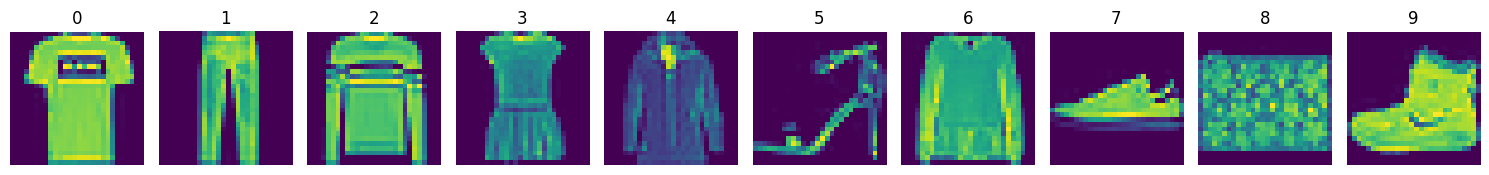

In [2]:
# downloaded the fashion_mnist dataset using keras and viewed the data shape and images

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()    # dividing between train and test for training later

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

# to show the images of all 10 classes
fig, axes = plt.subplots(1,10, figsize=(15,3))
for i in range(10):
    axes[i].imshow(x_train[y_train==i][0])
    axes[i].set_xlabel(f'Label: {y_train[y_train == i][0]}')
    axes[i].set_title(i)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

From the paper by Han Xiao et al. "Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms"
- 0 T-Shirt/Top
- 1 Trouser
- 2 Pullover
- 3 Dress
- 4 Coat
- 5 Sandals
- 6 Shirt
- 7 Sneaker
- 8 Bag
- 9 Ankle boots

### Question 2 - Configure a neural network

I implemented a modular NeuralNetwork class focusing on flexibility and modularity. One can easily tweak the depth and number of neurons per hidden layer by adjusting a simple list (e.g., [128, 64, 32]).
The architecture uses a dictionary-based lookup for activations, so switching between ReLU, Tanh, or Sigmoid or adding new ones in the future takes just a single line of code
Similarly, the loss computation is kept modular so other loss functions can be plugged in later. 
The network ends with a Softmax layer for class probabilities and caches intermediate states during forward() to make backprop and optimization straightforward.

In [3]:
# activation functions and their derivates

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1.0 - s)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

def softmax(x):
    # subtract max for numerical stability
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

# central lookup map for activations and gradients
ACTIVATIONS = {
    "relu": (relu, relu_derivative),
    "sigmoid": (sigmoid, sigmoid_derivative),
    "tanh": (tanh, tanh_derivative)
}


def cross_entropy_loss(y_hat, y):
    m = y.shape[0]
    eps = 1e-15
    # clip probabilities to avoid log(0) numerical instability
    y_hat_clipped = np.clip(y_hat, eps, 1.0 - eps)
    # mean cross-entropy loss
    loss = -np.mean(np.log(y_hat_clipped[np.arange(m), y]))
    # compute gradient of loss w.r.t. logits (dZ_out)
    y_one_hot = np.zeros_like(y_hat)
    y_one_hot[np.arange(m), y] = 1.0
    dZ_out = (y_hat - y_one_hot) / m
    
    return loss, dZ_out
    

class NeuralNetwork:
    def __init__(self, input_size=784, hidden_sizes=[128, 64, 32], output_size=10, activation="relu", weight_init="random"):
        self.layer_dims = [input_size] + hidden_sizes + [output_size]

        act = activation.lower()
        if act not in ACTIVATIONS:
            raise ValueError(f"Unsupported activation '{activation}'. Choose from {list(ACTIVATIONS.keys())}")
        self.act_fn, self.act_grad = ACTIVATIONS[act]

        self.weights = []
        self.biases = []

        init_mode = weight_init.lower()
        
        for din, dout in zip(self.layer_dims[:-1], self.layer_dims[1:]):
            # chosing weight initialization method
            if init_mode in ["xavier", "glorot"]:
                limit = np.sqrt(2.0 / (din + dout))
                W = np.random.randn(din, dout) * limit
            else:
                # random initialization
                W = np.random.randn(din, dout) * 0.01

            b = np.zeros((1, dout))
            self.weights.append(W)
            self.biases.append(b)

    
    def forward(self, X):
        A_list, H_list = [], [X]
        H = X
        
        # hidden layers (chosen activation)
        for W, b in zip(self.weights[:-1], self.biases[:-1]):
            A = np.dot(H, W) + b
            H = self.act_fn(A)
            A_list.append(A)
            H_list.append(H)
        
        # output layer (Softmax)
        A_out = np.dot(H, self.weights[-1]) + self.biases[-1]
        y_hat = softmax(A_out)
        
        A_list.append(A_out)
        H_list.append(y_hat)
        return y_hat, A_list, H_list

    def get_params(self):
        # flattened list of [W0, b0, W1, b1, ...] for optimizers
        params = []
        for W, b in zip(self.weights, self.biases):
            params.extend([W, b])
        return params
    
    def backward(self, dZ_out, A_list, H_list):
        dW_list, db_list = [], []
        dZ = dZ_out

        for i in reversed(range(len(self.weights))):
            H_prev = H_list[i]

            # gradients for current layer
            dW = np.dot(H_prev.T, dZ)
            db = np.sum(dZ, axis=0, keepdims=True)
            dW_list.insert(0, dW)
            db_list.insert(0, db)

            # remaining error to propagate backward
            if i > 0:
                dH_prev = np.dot(dZ, self.weights[i].T)
                dZ = dH_prev * self.act_grad(A_list[i-1])

        # flatten to match self.get_params() order
        grads = []
        for dW, db in zip(dW_list, db_list):
            grads.extend([dW, db])
        return grads

##### Sanity check: Running a forward pass on the training data

In [4]:
# flattening images to 784-d vectors and scale pixel values to [0, 1]
X_train = x_train.reshape(len(x_train), -1) / 255.0
X_test = x_test.reshape(len(x_test), -1) / 255.0

# initializing default 3-layer test model
model = NeuralNetwork(
    input_size=784, 
    hidden_sizes=[128, 64, 32], 
    output_size=10, 
    activation="relu",
    weight_init="xavier"
)
# model = NeuralNetwork(
#     input_size=784, 
#     hidden_sizes=[128, 64, 32], 
#     output_size=10, 
#     activation="tanh",
#     weight_init="random"
# )

probs, A_cache, H_cache = model.forward(X_train)

# verifying output dimensions and probability distribution
print(f"Output shape: {probs.shape}")
print(f"Sample 0 class probabilities:\n{np.round(probs[0], 4)}")
print(f"Probability sum check: {probs[0].sum():.6f}")

Output shape: (60000, 10)
Sample 0 class probabilities:
[0.0932 0.1236 0.0651 0.0794 0.0591 0.135  0.1019 0.1602 0.0711 0.1114]
Probability sum check: 1.000000


### Question 3 - Backpropagation

I have implemented all the optimizers present in the assignment sgd, momentum-based gradient descent, Nesterov accelerated gradient descent, rmsprop, adam, nadam.
In order to add any other optimzer like Eve is straightforward. One simply creates a class inheriting from Adam or Optimizer, initializes additional state buffers, and computes parameter updates inside _update() without altering any network or backprop code.

In [9]:
# helper to mirror parameter list shapes with zeros
def zeros_like_params(params):
    return [np.zeros_like(p) for p in params]

# base optimizer class
class Optimizer:
    def __init__(self, lr=0.001):
        self.lr = lr

    def initialize(self, params):
        pass  

    def step(self, params, grads):
        for i, (p, g) in enumerate(zip(params, grads)):
            g_clean = np.nan_to_num(g, nan=0.0, posinf=5.0, neginf=-5.0)
            g_clipped = np.clip(g_clean, -5.0, 5.0)
            self._update(i, p, g_clipped)

    def _update(self, i, p, g):
        raise NotImplementedError

# SGD optimizer class
class SGD(Optimizer):
    def _update(self, i, p, g):
        p -= self.lr * g

# Momentum optimizer class
class Momentum(Optimizer):
    def __init__(self, lr=0.001, momentum=0.9):
        super().__init__(lr)
        self.momentum = momentum

    def initialize(self, params):
        self.velocity = zeros_like_params(params)

    def _update(self, i, p, g):
        self.velocity[i] = self.momentum * self.velocity[i] - self.lr * g
        p += self.velocity[i]

# Nesterov Accelerated Gradient (NAG) optimizer class
class NAG(Momentum):
    def _update(self, i, p, g):
        v_prev = self.velocity[i]
        self.velocity[i] = self.momentum * v_prev - self.lr * g
        # Look-ahead update step
        p += -self.momentum * v_prev + (1.0 + self.momentum) * self.velocity[i]

# RMSProp optimizer class 
class RMSProp(Optimizer):
    def __init__(self, lr=0.001, beta=0.9, eps=1e-8):
        super().__init__(lr)
        self.beta = beta
        self.eps = eps

    def initialize(self, params):
        self.sq_grad = zeros_like_params(params)

    def _update(self, i, p, g):
        self.sq_grad[i] = self.beta * self.sq_grad[i] + (1.0 - self.beta) * (g ** 2)
        p -= self.lr * g / (np.sqrt(self.sq_grad[i]) + self.eps)

# Adam optimizer class
class Adam(Optimizer):
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        super().__init__(lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

    def initialize(self, params):
        self.m = zeros_like_params(params)
        self.v = zeros_like_params(params)
        self.t = 0

    def step(self, params, grads):
        self.t += 1
        super().step(params, grads)

    def _update(self, i, p, g):
        self.m[i] = self.beta1 * self.m[i] + (1.0 - self.beta1) * g
        self.v[i] = self.beta2 * self.v[i] + (1.0 - self.beta2) * (g ** 2)
        
        # bias corrections
        m_hat = self.m[i] / (1.0 - self.beta1 ** self.t)
        v_hat = self.v[i] / (1.0 - self.beta2 ** self.t)

        denom = np.sqrt(np.maximum(v_hat, 0.0)) + self.eps
        p -= self.lr * m_hat / denom

# Nadam optimizer class (Adam with Nesterov momentum)
class Nadam(Adam):
    def _update(self, i, p, g):
        self.m[i] = self.beta1 * self.m[i] + (1.0 - self.beta1) * g
        self.v[i] = self.beta2 * self.v[i] + (1.0 - self.beta2) * (g ** 2)
        
        # Nesterov-accelerated bias-corrected momentum
        m_hat = (self.beta1 * self.m[i] / (1.0 - self.beta1 ** self.t)) + \
                ((1.0 - self.beta1) * g / (1.0 - self.beta1 ** self.t))
        v_hat = self.v[i] / (1.0 - self.beta2 ** self.t)
        
        denom = np.sqrt(np.maximum(v_hat, 0.0)) + self.eps
        p -= self.lr * m_hat / denom

We can easily change the number of epochs and batch size by changing the value of EPOCHS and BATCH_SIZE which are defined globally.

In [10]:
EPOCHS = 10
BATCH_SIZE = 64
SEED = 42

# held out 10% of the training data for validation (54,000 train / 6,000 val)
X_tr, y_tr = X_train[:54000], y_train[:54000]
X_val, y_val = X_train[54000:], y_train[54000:]


def train(model, opt):
    params = model.get_params()
    opt.initialize(params)
    rng = np.random.default_rng(SEED)

    for epoch in range(1, EPOCHS + 1):
        order = rng.permutation(len(X_tr))
        total_loss = 0.0

        for s in range(0, len(order), BATCH_SIZE):
            batch_idx = order[s:s + BATCH_SIZE]
            y_hat, A_list, H_list = model.forward(X_tr[batch_idx])
            loss, dZ = cross_entropy_loss(y_hat, y_tr[batch_idx])
            
            grads = model.backward(dZ, A_list, H_list)
            opt.step(params, grads)
            
            total_loss += loss * len(batch_idx)

        # post-epoch validation check
        val_hat, _, _ = model.forward(X_val)
        val_loss, _ = cross_entropy_loss(val_hat, y_val)
        val_acc = (val_hat.argmax(axis=1) == y_val).mean()
        
        print(f"Epoch {epoch:2d}/{EPOCHS} | Train Loss: {total_loss / len(order):.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return val_acc


# compare optimizers with tuned learning rates
optimizers = {
    "SGD": SGD(lr=0.1),
    "Momentum": Momentum(lr=0.01, momentum=0.9),
    "NAG": NAG(lr=0.01, momentum=0.9),
    "RMSProp": RMSProp(lr=0.001),
    "Adam": Adam(lr=0.001),
    "Nadam": Nadam(lr=0.001),
}

results = {}
for name, opt in optimizers.items():
    print(f"\n--- Running {name} ---")
    np.random.seed(SEED)
    model = NeuralNetwork(input_size=784, hidden_sizes=[128, 64, 32], output_size=10)
    results[name] = train(model, opt)

print("\n--- Final Validation Benchmarks ---")
for name, acc in sorted(results.items(), key=lambda kv: kv[1], reverse=True):
    print(f"{name:<12}: {acc:.4f}")


--- Running SGD ---
Epoch  1/10 | Train Loss: 2.3030 | Val Loss: 2.3033 | Val Acc: 0.0925
Epoch  2/10 | Train Loss: 2.3018 | Val Loss: 2.2795 | Val Acc: 0.1363
Epoch  3/10 | Train Loss: 1.3940 | Val Loss: 0.9259 | Val Acc: 0.6128
Epoch  4/10 | Train Loss: 0.7113 | Val Loss: 0.6202 | Val Acc: 0.7612
Epoch  5/10 | Train Loss: 0.5291 | Val Loss: 0.5692 | Val Acc: 0.7903
Epoch  6/10 | Train Loss: 0.4412 | Val Loss: 0.4242 | Val Acc: 0.8510
Epoch  7/10 | Train Loss: 0.3989 | Val Loss: 0.4180 | Val Acc: 0.8535
Epoch  8/10 | Train Loss: 0.3736 | Val Loss: 0.3853 | Val Acc: 0.8668
Epoch  9/10 | Train Loss: 0.3507 | Val Loss: 0.3816 | Val Acc: 0.8635
Epoch 10/10 | Train Loss: 0.3355 | Val Loss: 0.3575 | Val Acc: 0.8752

--- Running Momentum ---
Epoch  1/10 | Train Loss: 2.3030 | Val Loss: 2.3033 | Val Acc: 0.0925
Epoch  2/10 | Train Loss: 2.3022 | Val Loss: 2.2928 | Val Acc: 0.1112
Epoch  3/10 | Train Loss: 1.3941 | Val Loss: 1.0100 | Val Acc: 0.6060
Epoch  4/10 | Train Loss: 0.6570 | Val Loss

### Question 4 - Hyperparameter sweep with wandb

Weights & Biases (W&B) Sweeps supports three core search methods (grid, random, and bayesian) to automate hyperparameter optimization, alongside advanced early stopping algorithms like hyperband to efficiently prune underperforming runs. (Source: Google)

So, I chose Bayesian Optimization paired with Hyperband early stopping for the hyperparameter search. Grid Search was computationally unfeasible due to the exponential number of parameter combinations, and Random Search does not leverage historical run performance. 

The Bayesian method constructs a probabilistic model to actively sample high-performing regions of the hyperparameter space. Hyperband further improves efficiency by benchmarking runs at early epochs and pruning underperforming configurations, allowing the sweep to explore more candidate configurations within the budget.

In [ ]:
os.environ["WANDB_SILENT"] = "true"

TOTAL_RUNS = 30
RUN_COUNT = 0

OPTIMIZERS = {
    "sgd": SGD, 
    "momentum": Momentum, 
    "nesterov": NAG,
    "rmsprop": RMSProp, 
    "adam": Adam, 
    "nadam": Nadam
}

# hyperparameter sweep configuration for Wandb
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_acc", "goal": "maximize"},
    "early_terminate": {"type": "hyperband", "min_iter": 3},
    "parameters": {
        "epochs":        {"values": [5, 10]},
        "num_layers":    {"values": [3, 4, 5]},
        "hidden_size":   {"values": [32, 64, 128]},
        "weight_decay":  {"values": [0, 0.0005, 0.5]},
        "learning_rate": {"values": [1e-3, 1e-4]},
        "optimizer":     {"values": ["sgd", "momentum", "nesterov", "rmsprop", "adam", "nadam"]},
        "batch_size":    {"values": [16, 32, 64]},
        "weight_init":   {"values": ["random", "Xavier"]},
        "activation":    {"values": ["sigmoid", "tanh", "relu"]},
    },
}

def sweep_train():
    global RUN_COUNT
    RUN_COUNT += 1
    
    wandb.init()
    cfg = wandb.config
    
    # formatted run name for Wandb UI dashboard
    wandb.run.name = f"run{RUN_COUNT}_{cfg.optimizer}_hl{cfg.num_layers}_sz{cfg.hidden_size}_{cfg.activation}_{cfg.weight_init}_bs{cfg.batch_size}_lr{cfg.learning_rate}_wd{cfg.weight_decay}"

    # initialize model architecture and optimizer
    model = NeuralNetwork(
        input_size=784, 
        hidden_sizes=[cfg.hidden_size] * cfg.num_layers, 
        output_size=10,
        activation=cfg.activation, 
        weight_init=cfg.weight_init
    )
    
    
    params = model.get_params()
    opt = OPTIMIZERS[cfg.optimizer](lr=cfg.learning_rate)
    opt.initialize(params)
    
    rng = np.random.default_rng()

    for epoch in range(1, cfg.epochs + 1):
        order = rng.permutation(len(X_tr))
        train_loss, train_correct = 0.0, 0

        # mini-batch training loop
        for s in range(0, len(order), cfg.batch_size):
            batch_idx = order[s:s + cfg.batch_size]
            
            y_hat, A_list, H_list = model.forward(X_tr[batch_idx])
            loss, dZ = cross_entropy_loss(y_hat, y_tr[batch_idx])
            grads = model.backward(dZ, A_list, H_list)

            # apply weight decay to weights only
            if cfg.weight_decay > 0:
                for i in range(0, len(grads), 2):
                    grads[i] += cfg.weight_decay * params[i]

            opt.step(params, grads)
            
            train_loss += loss * len(batch_idx)
            train_correct += (y_hat.argmax(axis=1) == y_tr[batch_idx]).sum()

        # validation pass
        val_hat, _, _ = model.forward(X_val)
        val_loss, _ = cross_entropy_loss(val_hat, y_val)
        val_acc = (val_hat.argmax(axis=1) == y_val).mean()

        # log epoch metrics to Wandb
        wandb.log({
            "epoch": epoch,
            "loss": train_loss / len(order),
            "accuracy": train_correct / len(order),
            "val_loss": val_loss,
            "val_acc": val_acc
        })

    # simple summary line printed only once per completed sweep run
    print(f"Run {RUN_COUNT}/{TOTAL_RUNS} [{cfg.optimizer}] finished - Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}")

# execute sweep
sweep_id = wandb.sweep(sweep_config, project="fashion-mnist-sweep")
wandb.agent(sweep_id, sweep_train, count=TOTAL_RUNS)

Create sweep with ID: tm4mj214
Sweep URL: https://wandb.ai/trishab/fashion-mnist-sweep/sweeps/tm4mj214
Run 1/30 [adam] finished - Val Acc: 0.1003 | Val Loss: 2.3027
Run 2/30 [nesterov] finished - Val Acc: 0.0925 | Val Loss: 2.3028
Run 3/30 [nesterov] finished - Val Acc: 0.8090 | Val Loss: 0.5414
Run 4/30 [adam] finished - Val Acc: 0.1032 | Val Loss: 2.3028
Run 5/30 [nesterov] finished - Val Acc: 0.8168 | Val Loss: 0.5206
Run 6/30 [sgd] finished - Val Acc: 0.1287 | Val Loss: 2.3016
Run 7/30 [rmsprop] finished - Val Acc: 0.8683 | Val Loss: 0.3689


In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

api = wandb.Api()
sweep = api.sweep("trishab/fashion-mnist-sweep/mybest")
best = sweep.best_run()
cfg = best.config

print(f"Best Run Config: {best.name} | Val Acc: {best.summary['val_acc']:.4f} | Val Loss: {best.summary['val_loss']:.4f}")

# retraining on full training data with best hyperparameters
np.random.seed(42)
final_model = NeuralNetwork(
    input_size=784,
    hidden_sizes=[cfg["hidden_size"]] * cfg["num_layers"],
    output_size=10,
    activation=cfg["activation"],
    weight_init=cfg["weight_init"]
)

opt = OPTIMIZERS[cfg["optimizer"]](lr=cfg["learning_rate"])
params = final_model.get_params()
opt.initialize(params)
rng = np.random.default_rng(42)

for epoch in range(1, cfg["epochs"] + 1):
    order = rng.permutation(len(X_train))
    total_loss = 0.0
    for s in range(0, len(order), cfg["batch_size"]):
        idx = order[s:s + cfg["batch_size"]]
        y_hat, A, H = final_model.forward(X_train[idx])
        loss, dZ = cross_entropy_loss(y_hat, y_train[idx])
        grads = final_model.backward(dZ, A, H)
        
        if cfg["weight_decay"] > 0:
            for i in range(0, len(grads), 2):
                grads[i] += cfg["weight_decay"] * params[i]
                
        opt.step(params, grads)
        total_loss += loss * len(idx)

    print(f"Epoch {epoch:2d}/{cfg['epochs']} | Train Loss: {total_loss / len(order):.4f}")

probs, _, _ = final_model.forward(X_test)
y_pred = probs.argmax(axis=1)
test_acc = (y_pred == y_test).mean()
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix assembly via numpy
cm = np.zeros((10, 10), dtype=int)
np.add.at(cm, (y_test, y_pred), 1)


precision = np.diag(cm) / np.maximum(cm.sum(axis=0), 1)
recall    = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
f1        = 2 * precision * recall / np.maximum(precision + recall, 1e-15)

print(f"\n{'Class':<14} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
for name, p, r, f in zip(class_names, precision, recall, f1):
    print(f"{name:<14} {p:<10.3f} {r:<10.3f} {f:<10.3f}")